# NHANES Data Assembly & Exploratory Analysis

**Data source:** CDC NHANES public-use files — 2011–2012 and 2013–2014 survey cycles.  
**Files expected:** `.xpt` (SAS transport) files under `data/raw/2011-2012/` and `data/raw/2013-2014/`.

### Notebook outline

| Step | Description |
|------|-------------|
| 1. Load | Read each cycle's `.xpt` tables and outer-merge within-cycle on `SEQN` |
| 2. Align | Inner-join columns present in both cycles, document dropped variables |
| 3. Rename | Map NHANES codes to readable column names |
| 4. Filter | Restrict to the fasting subsample (valid fasting glucose measurement) |
| 5. EDA | Missingness, biomarker distributions, correlations and CVD outcome prevalence |
| 6. Findings | Key observations and modelling implications |

In [34]:
%cd ~/Documents/biomarker-actionability

/Users/mkopy/Documents/biomarker-actionability


In [ ]:
%pip install -r ../requirements.txt

  Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl.metadata (17 kB)
  Using cached optuna-4.8.0-py3-none-any.whl.metadata (17 kB)
  Using cached shap-0.51.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (25 kB)
  Using cached tabpfn-7.1.1-py3-none-any.whl.metadata (41 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached torch-2.11.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (29 kB)
  Using cached einops-0.8.2-py3-none-any.whl.metadata (13 kB)
  Using cached eval_type_backport-0.3.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached tabpfn_common_utils-0.2.19-py3-none-any.whl.metadata (5.4 kB)


## 1. Load NHANES Data

In [69]:
import pandas as pd
import numpy as np
from pathlib import Path
from functools import reduce

In [71]:
def load_xpt(path):
    """Read a SAS XPORT file; replace SAS special-missing floats with NaN."""
    df = pd.read_sas(path, format='xport', encoding='latin-1')
    num_cols = df.select_dtypes(include='number').columns
    df[num_cols] = df[num_cols].where(df[num_cols].abs() > 1e-30, other=np.nan)
    return df

def merge_cycle(cycle_dir):
    """Outer-merge all .xpt tables in a cycle directory on participant ID (SEQN)."""
    files = sorted(Path(cycle_dir).glob("*.xpt"))
    tables = [load_xpt(f) for f in files]
    return reduce(lambda a, b: pd.merge(a, b, on='SEQN', how='outer'), tables)

df_2011 = merge_cycle("data/raw/2011-2012")
df_2013 = merge_cycle("data/raw/2013-2014")

print(f"2011–2012: {df_2011.shape[0]:,} rows × {df_2011.shape[1]:,} cols")
print(f"2013–2014: {df_2013.shape[0]:,} rows × {df_2013.shape[1]:,} cols")
df_2011.head(2)

2011–2012: 132,425 rows × 270 cols
2013–2014: 149,460 rows × 273 cols


,SEQN,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,...,SMQ664O,SMQ670,SMAQUEX2,LBXTC,LBDTCSI,WTSAF2YR_y,LBXTR,LBDTRSI,LBDLDL,LBDLDLSI
0,62161.0,1.0,69.2,NaN,NaN,NaN,NaN,NaN,172.3,NaN,...,NaN,NaN,1.0,168.0,4.34,240011.713,84.0,0.948,110.0,2.845
1,62161.0,1.0,69.2,NaN,NaN,NaN,NaN,NaN,172.3,NaN,...,NaN,NaN,1.0,168.0,4.34,240011.713,84.0,0.948,110.0,2.845


## 2. Cross-Cycle Column Alignment

**Goal:** combine both cycles into a single dataset using the column intersection (`pd.concat(..., join='inner')`).

**Key discrepancy: Insulin (`LBXIN` / `LBDINSI`):** collected in 2011–2012 only. Dropping it halves the insulin-measured sample but keeps ~282 k rows instead of ~132 k, this is a worthwhile trade for general metabolic modelling. To include insulin, restrict analysis to 2011–2012.

The audit below lists all variables unique to each cycle before the merge.

In [72]:
# --- Column audit: variables unique to each cycle ---
only_2011 = set(df_2011.columns) - set(df_2013.columns)
only_2013 = set(df_2013.columns) - set(df_2011.columns)

print(f"Columns only in 2011-2012 ({len(only_2011)}): {sorted(only_2011)}")
print(f"Columns only in 2013-2014 ({len(only_2013)}): {sorted(only_2013)}")
print(f"Shared columns: {len(set(df_2011.columns) & set(df_2013.columns))}")

# --- Combine cycles, keeping only columns present in both ---
df = pd.concat([df_2011, df_2013], join='inner', ignore_index=True)

print(f"\nCombined shape: {df.shape}")
df.head()

Columns only in 2011-2012 (17): ['BPQ057', 'BPQ150A', 'BPQ150B', 'BPQ150C', 'BPQ150D', 'LBDINSI', 'LBXIN', 'MCQ051', 'MCQ140', 'RIDEXAGY', 'SMQ077', 'SMQ660', 'SMQ664B', 'SMQ664C', 'SMQ664M', 'SMQ664O', 'SMQ664W']
Columns only in 2013-2014 (20): ['AGQ030', 'MCQ151', 'MCQ160O', 'MCQ203', 'MCQ206', 'RXDRSC1', 'RXDRSC2', 'RXDRSC3', 'RXDRSD1', 'RXDRSD2', 'RXDRSD3', 'SMQ078', 'SMQ661', 'SMQ665A', 'SMQ665B', 'SMQ665C', 'SMQ665D', 'SMQ848', 'SMQ852Q', 'SMQ852U']
Shared columns: 253

Combined shape: (281885, 253)


,SEQN,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,...,SMD630,SMQ670,SMAQUEX2,LBXTC,LBDTCSI,WTSAF2YR_y,LBXTR,LBDTRSI,LBDLDL,LBDLDLSI
0,62161.0,1.0,69.2,NaN,NaN,NaN,NaN,NaN,172.3,NaN,...,NaN,NaN,1.0,168.0,4.34,240011.713,84.0,0.948,110.0,2.845
1,62161.0,1.0,69.2,NaN,NaN,NaN,NaN,NaN,172.3,NaN,...,NaN,NaN,1.0,168.0,4.34,240011.713,84.0,0.948,110.0,2.845
2,62161.0,1.0,69.2,NaN,NaN,NaN,NaN,NaN,172.3,NaN,...,NaN,NaN,1.0,168.0,4.34,240011.713,84.0,0.948,110.0,2.845
3,62161.0,1.0,69.2,NaN,NaN,NaN,NaN,NaN,172.3,NaN,...,NaN,NaN,1.0,168.0,4.34,240011.713,84.0,0.948,110.0,2.845
4,62161.0,1.0,69.2,NaN,NaN,NaN,NaN,NaN,172.3,NaN,...,NaN,NaN,1.0,168.0,4.34,240011.713,84.0,0.948,110.0,2.845


## 3. Rename Columns

Map NHANES variable codes (e.g. `LBXTC`, `BMXBMI`) to readable names using `src/rename_columns.py`.

In [73]:
from src.rename_columns import rename_columns
df = rename_columns(df)

Renamed 253 columns. 0 columns unmapped.


## 4. Fasting Subsample

Filter to participants with a valid (non-NaN) fasting glucose measurement. All key metabolic markers (LDL, triglycerides, HbA1c) come from the same fasting blood draw, so this single filter cleans up missingness across the entire metabolic panel.

**Survey weights:** for population-representative estimates use `weight_fasting_2yr_glucose` (NHANES variable `WTSAF2YR_x`), the 2-year weight designed for the fasting subsample.

> ~60% of participants are dropped; the remaining ~116 k rows are internally consistent for all metabolic analyses.

In [74]:
n_before = len(df)
df = df[df['fasting_glucose_mg_dl'].notna()].reset_index(drop=True)
n_after = len(df)

print(f"Before fasting filter : {n_before:>7,} rows")
print(f"After  fasting filter : {n_after:>7,} rows")
print(f"Dropped               : {n_before - n_after:>7,} rows ({(n_before - n_after) / n_before:.1%})")
print(f"\nFasting weight column : weight_fasting_2yr_glucose")
print(f"  Non-null            : {df['weight_fasting_2yr_glucose'].notna().sum():,}")
print(f"  Min / Max           : {df['weight_fasting_2yr_glucose'].min():.1f} / {df['weight_fasting_2yr_glucose'].max():.1f}")

Before fasting filter : 281,885 rows
After  fasting filter : 115,700 rows
Dropped               : 166,185 rows (59.0%)

Fasting weight column : weight_fasting_2yr_glucose
  Non-null            : 107,923
  Min / Max           : 10219.1 / 521033.4


## 5. Exploratory Analysis

| Plot | Purpose |
|------|---------|
| **Missingness** | Verify the fasting filter cleaned up metabolic markers |
| **Biomarker distributions** | Spot skew, outliers, and position relative to clinical thresholds |
| **Correlation matrix** | Identify redundant features (high Pearson r = little independent information) |
| **CVD outcome prevalence** | Confirm the outcome is well-defined and not severely imbalanced |

### Clinical decision thresholds

Vertical cutoff lines in the biomarker plots follow these published guidelines:

| Marker | Cutoffs | Guideline |
|--------|---------|-----------|
| Total cholesterol | 200 (borderline), 240 mg/dL (high) | Stone NJ et al. *JACC* 2014 (ACC/AHA 2013 cholesterol guideline) |
| HDL cholesterol | <40 mg/dL (low, men); ≥60 mg/dL (protective) | Stone NJ et al. *JACC* 2014 |
| LDL cholesterol | 100 (optimal), 130 (borderline), 160 mg/dL (high) | Stone NJ et al. *JACC* 2014 |
| Triglycerides | 150 (borderline high), 200 mg/dL (high) | Grundy SM et al. *Circulation* 2019 (AHA/ACC 2018 multisociety guideline) |
| Fasting glucose | 100 (prediabetes), 126 mg/dL (diabetes) | ADA *Standards of Medical Care in Diabetes* 2024 |
| HbA1c | 5.7% (prediabetes), 6.5% (diabetes) | ADA *Standards of Medical Care in Diabetes* 2024 |
| BMI | 18.5 (underweight), 25 (overweight), 30 kg/m² (obese) | WHO Global BMI Classification |
| Systolic BP | 130 (Stage 1 HTN), 140 mmHg (Stage 2 HTN) | Whelton PK et al. *JACC* 2018 (ACC/AHA 2017 HTN guideline) |

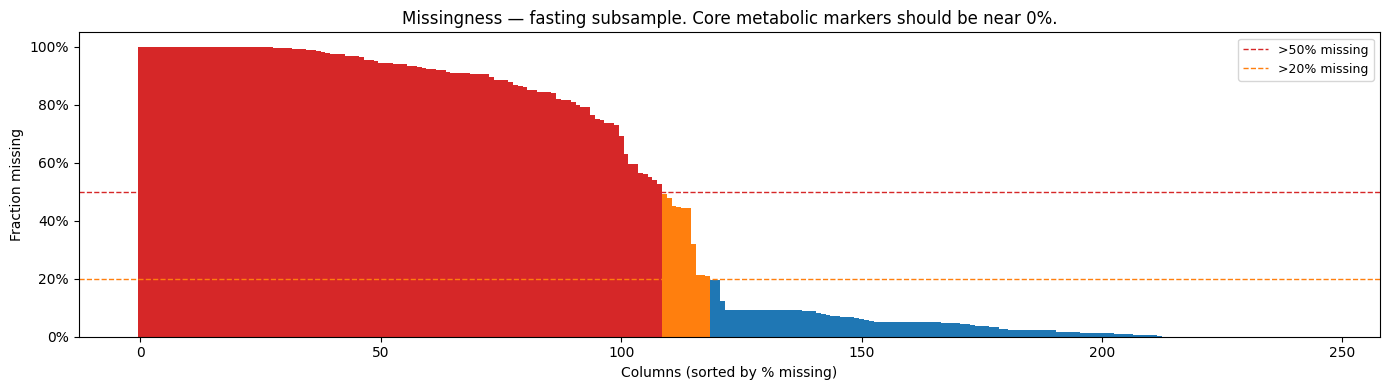

Missingness in core fasting markers:
  fasting_glucose_mg_dl               0.00%
  hba1c_pct                           0.23%
  total_cholesterol_mg_dl             1.37%
  hdl_mg_dl                           1.37%
  ldl_mg_dl                           3.32%
  triglycerides_mg_dl                 1.50%


In [75]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Missingness across all numeric columns, sorted descending
nan_pct = df.select_dtypes(include='number').isnull().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#d62728' if v > 0.50 else '#ff7f0e' if v > 0.20 else '#1f77b4' for v in nan_pct.values]
ax.bar(range(len(nan_pct)), nan_pct.values, color=colors, width=1.0)
ax.axhline(0.50, color='#d62728', linestyle='--', linewidth=1, label='>50% missing')
ax.axhline(0.20, color='#ff7f0e', linestyle='--', linewidth=1, label='>20% missing')
ax.set_xlabel("Columns (sorted by % missing)")
ax.set_ylabel("Fraction missing")
ax.set_title("Missingness — fasting subsample. Core metabolic markers should be near 0%.")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Spot-check core fasting markers
fasting_markers = [
    'fasting_glucose_mg_dl', 'hba1c_pct', 'total_cholesterol_mg_dl',
    'hdl_mg_dl', 'ldl_mg_dl', 'triglycerides_mg_dl',
]
print("Missingness in core fasting markers:")
for col in fasting_markers:
    if col in df.columns:
        print(f"  {col:<35} {df[col].isnull().mean():.2%}")

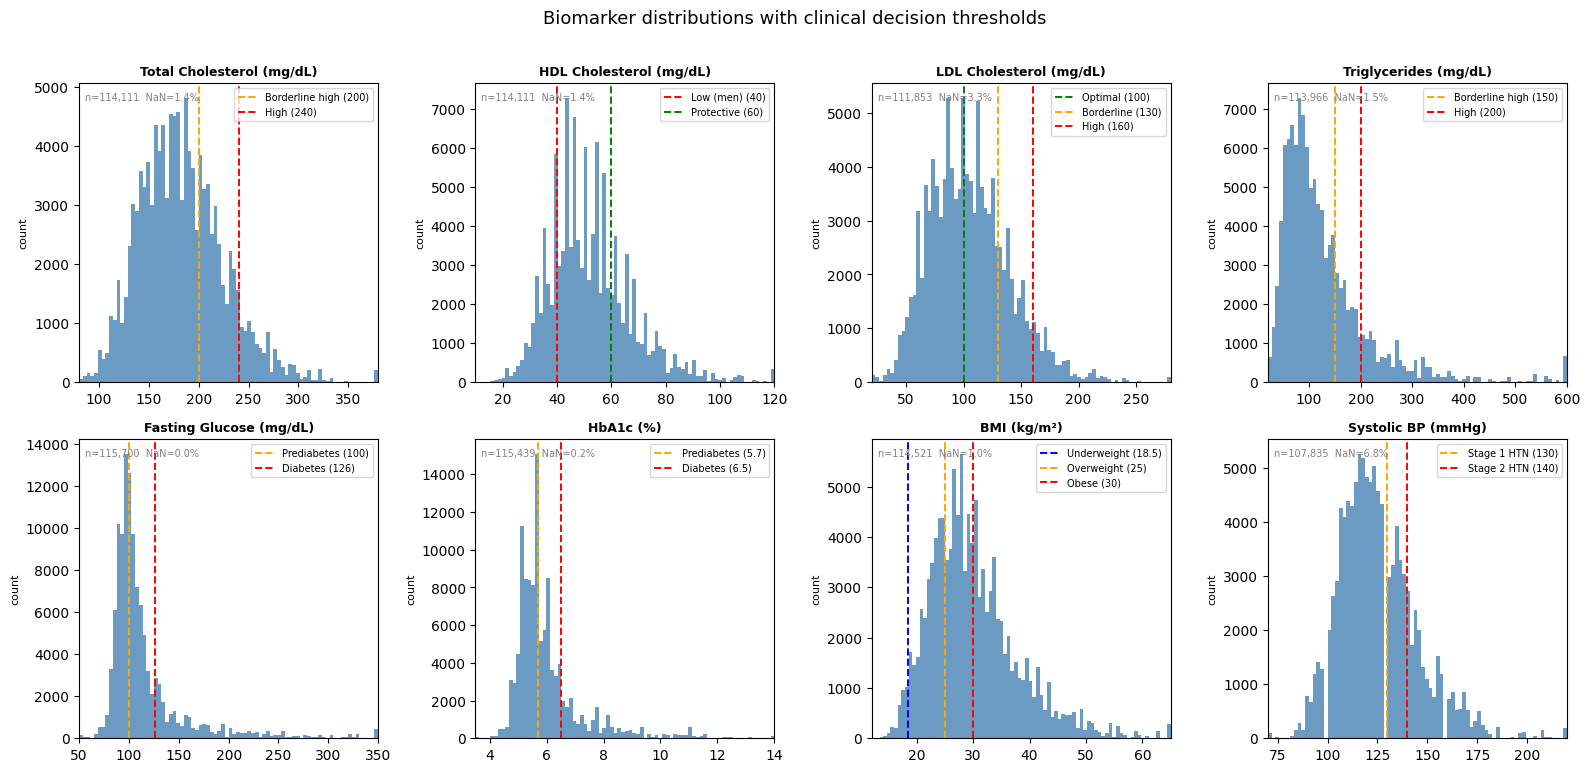

In [76]:
# Thresholds and sources are documented in the clinical decision thresholds table above.
BIOMARKERS = {
    # Stone NJ et al. JACC 2014 (ACC/AHA 2013)
    'total_cholesterol_mg_dl': {
        'label': 'Total Cholesterol (mg/dL)',
        'cutoffs': [(200, 'Borderline high', 'orange'), (240, 'High', 'red')],
        'xlim': (80, 380),
    },
    # Stone NJ et al. JACC 2014 (ACC/AHA 2013)
    'hdl_mg_dl': {
        'label': 'HDL Cholesterol (mg/dL)',
        'cutoffs': [(40, 'Low (men)', 'red'), (60, 'Protective', 'green')],
        'xlim': (10, 120),
    },
    # Stone NJ et al. JACC 2014 (ACC/AHA 2013)
    'ldl_mg_dl': {
        'label': 'LDL Cholesterol (mg/dL)',
        'cutoffs': [(100, 'Optimal', 'green'), (130, 'Borderline', 'orange'), (160, 'High', 'red')],
        'xlim': (20, 280),
    },
    # Grundy SM et al. Circulation 2019 (AHA/ACC 2018)
    'triglycerides_mg_dl': {
        'label': 'Triglycerides (mg/dL)',
        'cutoffs': [(150, 'Borderline high', 'orange'), (200, 'High', 'red')],
        'xlim': (20, 600),
    },
    # ADA Standards of Medical Care 2024
    'fasting_glucose_mg_dl': {
        'label': 'Fasting Glucose (mg/dL)',
        'cutoffs': [(100, 'Prediabetes', 'orange'), (126, 'Diabetes', 'red')],
        'xlim': (50, 350),
    },
    # ADA Standards of Medical Care 2024
    'hba1c_pct': {
        'label': 'HbA1c (%)',
        'cutoffs': [(5.7, 'Prediabetes', 'orange'), (6.5, 'Diabetes', 'red')],
        'xlim': (3.5, 14),
    },
    # WHO Global BMI Classification
    'bmi': {
        'label': 'BMI (kg/m²)',
        'cutoffs': [(18.5, 'Underweight', 'blue'), (25, 'Overweight', 'orange'), (30, 'Obese', 'red')],
        'xlim': (12, 65),
    },
    # Whelton PK et al. JACC 2018 (ACC/AHA 2017 HTN guideline)
    'systolic_bp_1': {
        'label': 'Systolic BP (mmHg)',
        'cutoffs': [(130, 'Stage 1 HTN', 'orange'), (140, 'Stage 2 HTN', 'red')],
        'xlim': (70, 220),
    },
}

present = {k: v for k, v in BIOMARKERS.items() if k in df.columns}
ncols = 4
nrows = -(-len(present) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.8))
axes = axes.flatten()

for ax, (col, meta) in zip(axes, present.items()):
    data = df[col].dropna()
    lo, hi = meta['xlim']
    ax.hist(data.clip(lo, hi), bins=80, color='steelblue', edgecolor='none', alpha=0.8)
    for val, lbl, color in meta['cutoffs']:
        ax.axvline(val, color=color, linestyle='--', linewidth=1.4, label=f'{lbl} ({val})')
    ax.set_title(meta['label'], fontsize=9, fontweight='bold')
    ax.set_xlim(lo, hi)
    ax.set_ylabel('count', fontsize=8)
    ax.legend(fontsize=7, loc='upper right')
    ax.text(0.02, 0.97, f'n={len(data):,}  NaN={df[col].isnull().mean():.1%}',
            transform=ax.transAxes, va='top', fontsize=7, color='grey')

for ax in axes[len(present):]:
    ax.set_visible(False)

plt.suptitle("Biomarker distributions with clinical decision thresholds", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

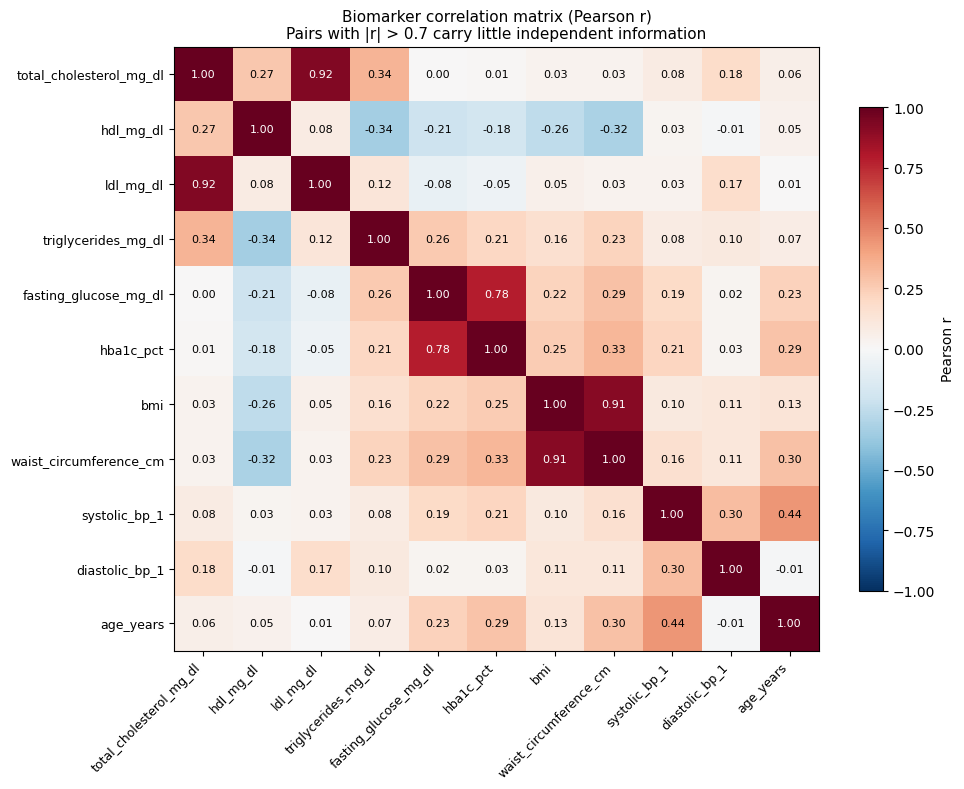

Highly correlated pairs (|r| > 0.7):
  total_cholesterol_mg_dl <-> ldl_mg_dl: r=0.924
  fasting_glucose_mg_dl <-> hba1c_pct: r=0.783
  bmi <-> waist_circumference_cm: r=0.913


In [77]:
biomarker_cols = [c for c in [
    'total_cholesterol_mg_dl', 'hdl_mg_dl', 'ldl_mg_dl', 'triglycerides_mg_dl',
    'fasting_glucose_mg_dl', 'hba1c_pct', 'bmi', 'waist_circumference_cm',
    'systolic_bp_1', 'diastolic_bp_1', 'age_years',
] if c in df.columns]

corr = df[biomarker_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
ax.set_xticks(range(len(biomarker_cols)))
ax.set_yticks(range(len(biomarker_cols)))
ax.set_xticklabels(biomarker_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(biomarker_cols, fontsize=9)
for i in range(len(biomarker_cols)):
    for j in range(len(biomarker_cols)):
        val = corr.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(val) > 0.6 else 'black')
ax.set_title("Biomarker correlation matrix (Pearson r)\nPairs with |r| > 0.7 carry little independent information", fontsize=11)
plt.tight_layout()
plt.show()

print("Highly correlated pairs (|r| > 0.7):")
for i in range(len(biomarker_cols)):
    for j in range(i + 1, len(biomarker_cols)):
        r = corr.values[i, j]
        if abs(r) > 0.7:
            print(f"  {biomarker_cols[i]} <-> {biomarker_cols[j]}: r={r:.3f}")

/var/folders/4y/nymvqk450fqbwplvxh1fsv100000gn/T/ipykernel_85510/488059820.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cvd_hard'] = (
/var/folders/4y/nymvqk450fqbwplvxh1fsv100000gn/T/ipykernel_85510/488059820.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cvd_composite'] = (
/var/folders/4y/nymvqk450fqbwplvxh1fsv100000gn/T/ipykernel_85510/488059820.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Conside

Component prevalence (% of participants with valid response):
  MI        10,673 / 104,886  (10.2%)
  Stroke     8,756 / 104,886  (8.3%)
  CHD       10,451 / 104,886  (10.0%)
  Statin    71,828 /  92,990  (77.2%)

Hard CVD  (primary)   : 18.2%  (n=21,085)
Composite (sensitivity): 65.3%  (n=75,562)


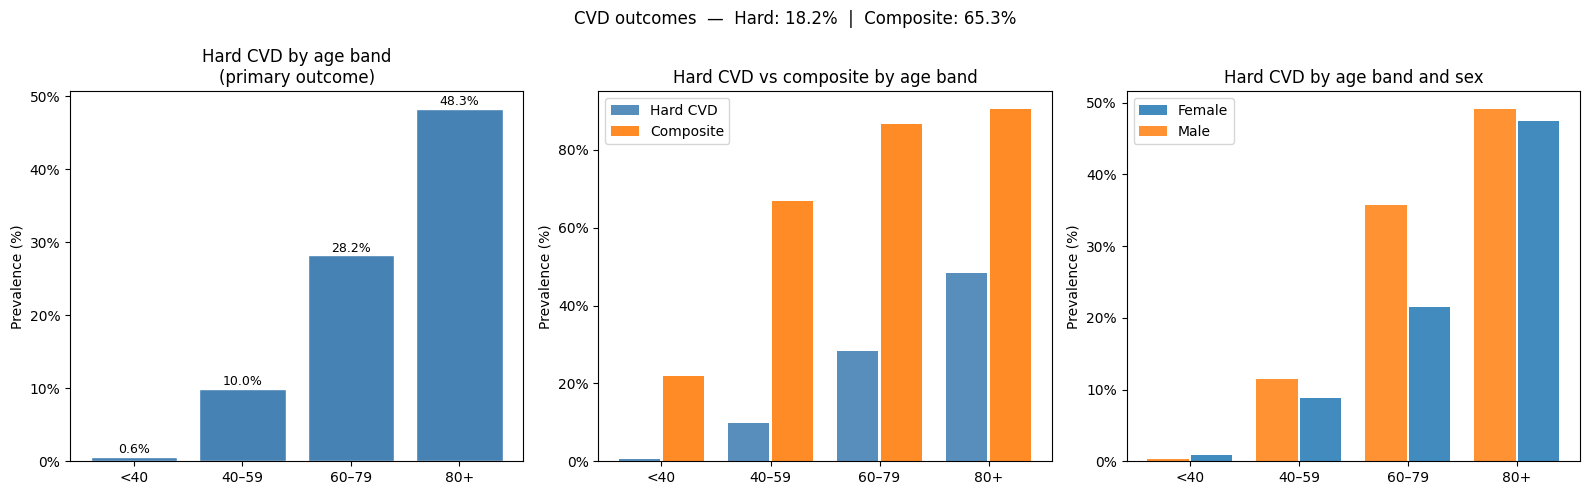

In [78]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Outcome definitions ───────────────────────────────────────────────────────
# NHANES coding: 1 = Yes, 2 = No, 7/9 = Refused/Don't know → treat non-1 as negative

# Hard CVD (primary outcome): actual diagnosed cardiovascular events
df['cvd_hard'] = (
    (df['ever_told_heart_attack'] == 1) |
    (df['ever_told_stroke'] == 1) |
    (df['ever_told_coronary_heart_disease'] == 1)
).astype(int)

# Composite CVD (sensitivity analysis): hard events + statin use as high-risk proxy
df['cvd_composite'] = (
    (df.get('ever_told_heart_attack',           pd.Series(0, index=df.index)) == 1) |
    (df.get('ever_told_stroke',                 pd.Series(0, index=df.index)) == 1) |
    (df.get('ever_told_coronary_heart_disease', pd.Series(0, index=df.index)) == 1) |
    (df.get('taking_cholesterol_medication',    pd.Series(0, index=df.index)) == 1)
).astype(int)

# ── Component breakdown ───────────────────────────────────────────────────────
print("Component prevalence (% of participants with valid response):")
for label, col in [
    ('MI',     'ever_told_heart_attack'),
    ('Stroke', 'ever_told_stroke'),
    ('CHD',    'ever_told_coronary_heart_disease'),
    ('Statin', 'taking_cholesterol_medication'),
]:
    pos   = (df[col] == 1).sum()
    valid = df[col].notna().sum()
    print(f"  {label:<8} {pos:>7,} / {valid:>7,}  ({pos/valid:.1%})")

print(f"\nHard CVD  (primary)   : {df['cvd_hard'].mean():.1%}  (n={df['cvd_hard'].sum():,})")
print(f"Composite (sensitivity): {df['cvd_composite'].mean():.1%}  (n={df['cvd_composite'].sum():,})")

# ── Age and sex breakdown ─────────────────────────────────────────────────────
df['age_band']  = pd.cut(df['age_years'], bins=[0, 39, 59, 79, 120], labels=['<40', '40–59', '60–79', '80+'])
df['sex_label'] = df['sex'].map({1.0: 'Male', 2.0: 'Female'})

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: hard CVD by age band
age_hard = df.groupby('age_band', observed=True)['cvd_hard'].mean()
axes[0].bar(age_hard.index.astype(str), age_hard.values * 100, color='steelblue', edgecolor='white')
for i, v in enumerate(age_hard.values):
    axes[0].text(i, v * 100 + 0.5, f'{v:.1%}', ha='center', fontsize=9)
axes[0].set_title('Hard CVD by age band\n(primary outcome)')
axes[0].set_ylabel('Prevalence (%)')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# Centre: hard vs composite side-by-side by age band
x = np.arange(len(age_hard))
age_comp = df.groupby('age_band', observed=True)['cvd_composite'].mean()
axes[1].bar(x - 0.2, age_hard.values * 100,  width=0.38, label='Hard CVD',  color='steelblue', alpha=0.9)
axes[1].bar(x + 0.2, age_comp.values * 100, width=0.38, label='Composite', color='#ff7f0e',   alpha=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(age_hard.index.astype(str))
axes[1].set_title('Hard CVD vs composite by age band')
axes[1].set_ylabel('Prevalence (%)')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
axes[1].legend()

# Right: hard CVD by age band and sex
prev_table = (
    df.groupby(['age_band', 'sex_label'], observed=True)['cvd_hard']
    .mean().reset_index()
)
for sex, grp in prev_table.groupby('sex_label'):
    offset = -0.2 if sex == 'Male' else 0.2
    axes[2].bar(np.arange(len(grp)) + offset, grp['cvd_hard'] * 100,
                width=0.38, label=sex, alpha=0.85)
axes[2].set_xticks(np.arange(4))
axes[2].set_xticklabels(age_hard.index.astype(str))
axes[2].set_title('Hard CVD by age band and sex')
axes[2].set_ylabel('Prevalence (%)')
axes[2].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
axes[2].legend()

plt.suptitle(
    f"CVD outcomes  —  Hard: {df['cvd_hard'].mean():.1%}  |  Composite: {df['cvd_composite'].mean():.1%}",
    fontsize=12
)
plt.tight_layout()
plt.show()

## 6. Key Findings & Modelling Implications

### Dataset
- **115,700 participants** retained after fasting filter (59% of combined 2011–2014 sample)
- 253 variables shared across both cycles, insulin dropped due to cycle mismatch

---

### Cardiometabolic burden is high
The fasting subsample captures a population with substantial metabolic risk:

| Marker | Median | % at or above key threshold |
|--------|--------|----------------------------|
| Fasting glucose | 102 mg/dL | **57.5%** ≥ 100 mg/dL (prediabetes range) |
| HbA1c | 5.7% | **51.2%** ≥ 5.7% (prediabetes range) |
| BMI | 28.6 kg/m² | **43.2%** ≥ 30 (obese) |
| Systolic BP | 122 mmHg | **35.7%** ≥ 130 mmHg (Stage 1 HTN) |
| Triglycerides | 104 mg/dL | **27.1%** ≥ 150 mg/dL (borderline high) |
| Total cholesterol | 179 mg/dL | **32.0%** ≥ 200 mg/dL (borderline high) |

The median fasting glucose (102 mg/dL) and HbA1c (5.7%) both sit  at the ADA prediabetes threshold.

---

### Outcome definition: hard CVD is the primary outcome

Two outcomes are constructed, they measure fundamentally different things:

| Outcome | Prevalence | Definition |
|---------|-----------|-----------|
| **Hard CVD** (primary) | **18.2%** | MI \| Stroke \| CHD — actual diagnosed events |
| Composite (sensitivity) | 65.3% | Hard CVD + statin use as high-risk proxy |

The composite is dominated by statin use: **77.2%** of the valid statin subsample are on cholesterol-lowering medication. Someone on a statin for mildly elevated cholesterol is clinically very different from someone who survived a heart attack and conflating them degrades both outcome validity and DCA interpretability.

**Why 65.3% breaks decision curve analysis:** when prevalence is this high, the treat-all strategy already achieves high net benefit across most threshold probabilities, leaving almost no room for a biomarker-guided strategy to add value. The 18.2% hard CVD prevalence sits comfortably in the range where DCA can discriminate between strategies.

**Hard CVD age and sex patterns are clinically coherent:**

| Age band | Hard CVD |
|----------|---------|
| < 40 | 0.6% |
| 40–59 | 10.0% |
| 60–79 | 28.2% |
| 80+ | 48.3% |

Males (21.9%) have meaningfully higher hard CVD prevalence than females (15.0%), consistent with known epidemiology, unlike the composite, which showed the reverse.

**Analytic plan:** run the full modelling pipeline on both outcomes. Hard CVD is the primary analysis, composite is the sensitivity analysis to assess whether including treatment burden changes the conclusions.

---

### Redundant features to manage in modelling

Three feature pairs are near-collinear and carry little independent information:

| Pair | Pearson r | Implication |
|------|-----------|-------------|
| Total cholesterol ↔ LDL | **0.924** | LDL subsumes total cholesterol; consider dropping one |
| BMI ↔ Waist circumference | **0.913** | Interchangeable measures of adiposity |
| Fasting glucose ↔ HbA1c | **0.783** | Both reflect glycaemic control, include one or engineer a composite |

Tree-based models (LightGBM, TabPFN) handle collinearity natively, but redundant features can distort SHAP attributions; prefer to keep one from each pair for interpretability.